In [8]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch

In [2]:
def hl2_prime(n, z):
    return (n / z) * hankel2(n, z) - hankel2(n + 1, z) # derivative for hankel function of second kind
def hl1_prime(n, z):
    return (n / z) * hankel1(n, z) - hankel1(n + 1, z) # derivative for hankel function of first kind

We verify the hankel function derivatives by comparing them between numeric/analytic results

In [58]:
numerical_derivatives_1 = zeros(100, dtype=complex)
analytic_derivatives_1 = zeros(100, dtype=complex)
numerical_derivatives_2 = zeros(100, dtype=complex)
analytic_derivatives_2 = zeros(100, dtype=complex)

deltax = 0.01
for i in range(0, 100):
    x = 0.1 + i/10
    l = 1
    numerical_derivatives_1[i] = (hankel2(l, x+deltax/2) - hankel2(l, x-deltax/2))/deltax
    analytic_derivatives_1[i] = hl2_prime(l, x)

    l = 2
    numerical_derivatives_2[i] = (hankel2(l, x+deltax/2) - hankel2(l, x-deltax/2))/deltax
    analytic_derivatives_2[i] = hl2_prime(l, x)

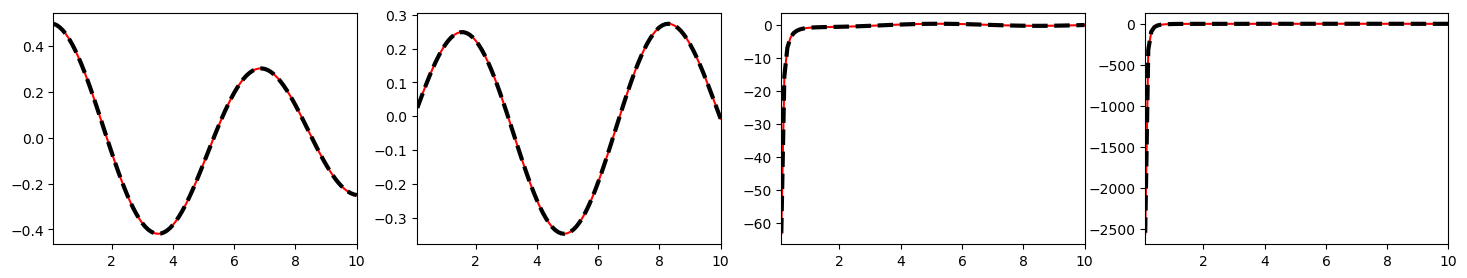

In [60]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 3))
x = linspace(0.1, 10, 100, endpoint=True)
ax1.plot(x, numerical_derivatives_1.real, color="red")
ax1.plot(x, analytic_derivatives_1.real, linestyle="dashed", linewidth=3, color="black")
ax1.set_xlim(0.1, 10)

ax3.plot(x, numerical_derivatives_1.imag, color="red")
ax3.plot(x, analytic_derivatives_1.imag, linestyle="dashed", linewidth=3, color="black")
ax3.set_xlim(0.1, 10)

ax2.plot(x, numerical_derivatives_2.real, color="red")
ax2.plot(x, analytic_derivatives_2.real, linestyle="dashed", linewidth=3, color="black");
ax2.set_xlim(0.1, 10)

ax4.plot(x, numerical_derivatives_2.imag, color="red")
ax4.plot(x, analytic_derivatives_2.imag, linestyle="dashed", linewidth=3, color="black");
ax4.set_xlim(0.1, 10);

## We find the CPA condition in a range including kR = 0.3 for real(eps) = -1.14 and l = 1

In [86]:
M = N = 1000
x = np.linspace(0.01, 0.5, M) # Free space kR 

min_vals = zeros(N)
imepsv = linspace(0, 0.2, N)
l = 1 # order of mode (bessel/hankel function)

for (i, imeps) in enumerate(imepsv):
    epsilon = -1.14 + imeps*1j
    y = x * sqrt(epsilon) # epsilonkR in the cylinder
        
    lhs = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x) # Left hand side of equation 1
    rhs =  jvp(l, y, 1) * hankel2(l, x) # Right hand side of equation 1
    min_vals[i] = min(np.abs(rhs-lhs))

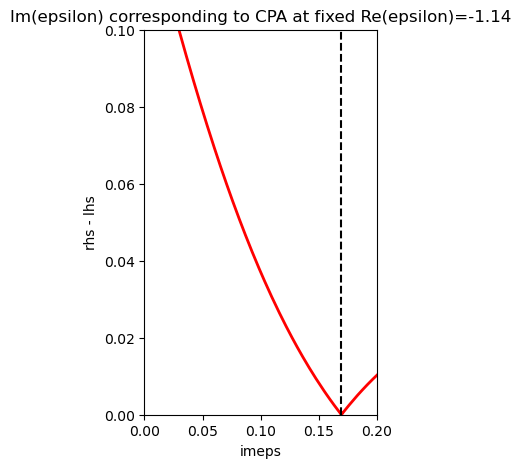

In [88]:
plt.figure(figsize=(3, 5))
plt.plot(imepsv, min_vals, color="red", linewidth=2)
plt.ylim(0, 0.1)
plt.xlim(0, 0.2)
plt.vlines([imepsv[np.argmin(min_vals)]], 0, 0.1, linestyle="dashed", color="black")
plt.ylabel("rhs - lhs")
plt.xlabel("imeps");
plt.title("Im(epsilon) corresponding to CPA at fixed Re(epsilon)=-1.14");

In [89]:
print(f"Optimal imaginary value for epsilon given by: {imepsv[np.argmin(min_vals)]}")

Optimal imaginary value for epsilon given by: 0.1693693693693694


In [90]:
epsilon = -1.14 + imepsv[np.argmin(min_vals)]*1j # Fix to optimal epsilon (given fixed real part)
y = x * sqrt(epsilon) # epsilonkR in the cylinder
    
lhs = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
rhs =  jvp(l, y, 1) * hankel2(l, x)

In [91]:
print(f"Optimal value of kR at optimal expsilon: {x[np.argmin(abs(lhs-rhs))]}")

Optimal value of kR at optimal expsilon: 0.3096896896896897


## Visualizing the dip in the numerator of s as a function of kR at fixed dielectric function

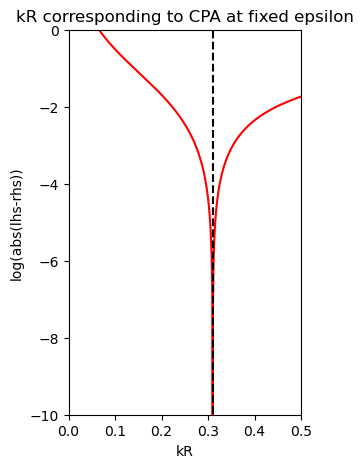

In [94]:
plt.figure(figsize=(3, 5))
plt.plot(x, np.log(abs(lhs-rhs)), color="red")
plt.xlim(0, 0.5)
plt.vlines([x[np.argmin(abs(lhs-rhs))]], -20, 0, linestyle="dashed", color="black")
plt.ylim(-10, 0);
plt.xlabel("kR");
plt.ylabel("log(abs(lhs-rhs))");
plt.title("kR corresponding to CPA at fixed epsilon");

## Linewidth of |s|^2 for l=1 CPA condition

In [95]:
x = np.linspace(0.01, 1, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

epsilon = -1.14 + imepsv[np.argmin(min_vals)]*1j
lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
rhs_num =  jvp(l, y, 1) * hankel2(l, x)

lhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
rhs_denom =  jvp(l, y, 1) * hankel1(l, x)

s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)

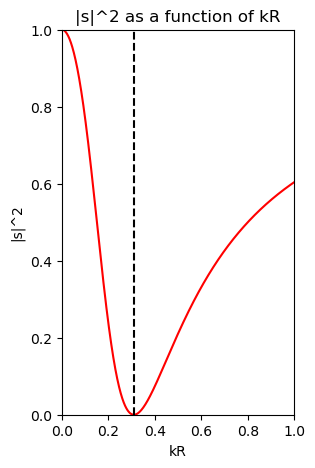

In [108]:
plt.figure(figsize=(3, 5))
plt.plot(x, abs(s)**2, color="red")
plt.ylim(0, 1);
plt.xlim(0, 1);
plt.vlines([x[np.argmin(abs(s)**2)]], 0, 1, color="black", linestyle="dashed")
plt.title("|s|^2 as a function of kR")
plt.xlabel("kR")
plt.ylabel("|s|^2");
#plt.ylim(0, 1)

## We do the same as the above for l = 2. First, we find the optimal im(eps) for fixed Re(eps) = -1.03

In [109]:
M = N = 1000
x = np.linspace(0.01, 0.5, M) # Free space kR

min_vals = zeros(N)
imepsv = linspace(0, 0.004, N)
l = 2 # order of mode (bessel/hankel function)

for (i, imeps) in enumerate(imepsv):
    epsilon = -1.03 + imeps*1j
    y = x * sqrt(epsilon) # epsilonkR in the cylinder
        
    lhs = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
    rhs =  jvp(l, y, 1) * hankel2(l, x)
    min_vals[i] = min(np.abs(rhs-lhs))

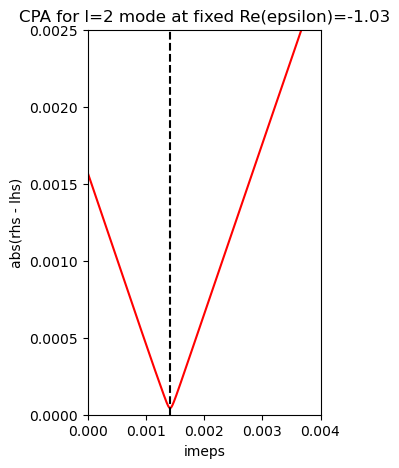

In [122]:
plt.figure(figsize=(3, 5))
plt.plot(imepsv, min_vals, color="red")
plt.vlines([imepsv[np.argmin(min_vals)]], 0, 1, linestyle="dashed", color="black")
plt.ylim(0, 0.0025)
plt.xlim(0, 0.004)
plt.ylabel("abs(rhs - lhs)")
plt.xlabel("imeps");
plt.title("CPA for l=2 mode at fixed Re(epsilon)=-1.03");

In [123]:
print(f"Im(epsilon) corresponding to CPA (for l=2 mode, real value of epsilon fixed to -1.03): {imepsv[np.argmin(min_vals)]}")

Im(epsilon) corresponding to CPA (for l=2 mode, real value of epsilon fixed to -1.03): 0.0014134134134134134


In [124]:
epsilon = -1.03 + imepsv[np.argmin(min_vals)]*1j
y = x * sqrt(epsilon) # epsilonkR in the cylinder
    
lhs = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
rhs =  jvp(l, y, 1) * hankel2(l, x)

In [125]:
x[np.argmin(abs(lhs-rhs))]

0.2900700700700701

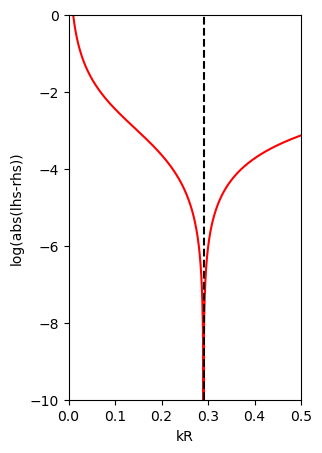

In [134]:
plt.figure(figsize=(3, 5))
plt.plot(x, np.log(abs(lhs-rhs)), color="red")
plt.ylim(-10, 0)
plt.xlim(0, 0.5);
plt.vlines([x[np.argmin(abs(lhs-rhs))]], -10, 0, color="black", linestyle="dashed");
plt.xlabel("kR")
plt.ylabel("log(abs(lhs-rhs))");

In [135]:
l = 2
x = np.linspace(0.01, 1, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder

epsilon = -1.03 + imepsv[np.argmin(min_vals)]*1j
lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
rhs_num =  jvp(l, y, 1) * hankel2(l, x)

lhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
rhs_denom =  jvp(l, y, 1) * hankel1(l, x)

s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)

## Figure 4a

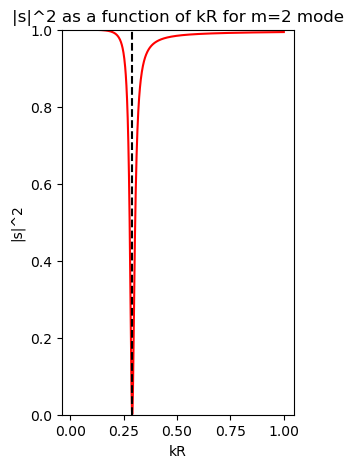

In [141]:
plt.figure(figsize=(3, 5))
plt.plot(x, abs(s)**2, color="red")
plt.ylim(0, 1);
plt.xlabel("kR")
plt.ylabel("|s|^2");
plt.title("|s|^2 as a function of kR for m=2 mode");
plt.vlines([x[np.argmin(abs(s)**2)]], 0, 1, color="black", linestyle="dashed");

#plt.ylim(0, 1)